First 5 Rows:
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

Shape of Dataset:
(4521, 17)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45

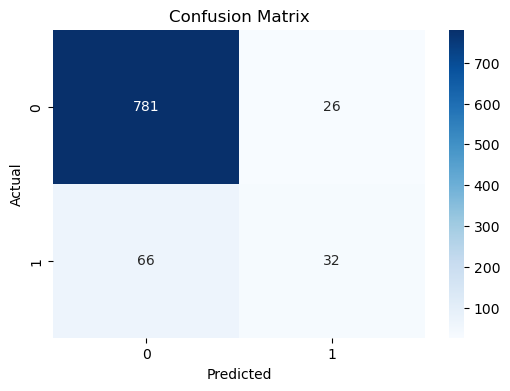


Feature Importance:
      Feature  Importance
11   duration    0.490278
13      pdays    0.134362
15   poutcome    0.114261
0         age    0.098535
10      month    0.051858
9         day    0.042169
5     balance    0.038101
8     contact    0.013163
12   campaign    0.009616
6     housing    0.007658
1         job    0.000000
2     marital    0.000000
3   education    0.000000
4     default    0.000000
7        loan    0.000000
14   previous    0.000000


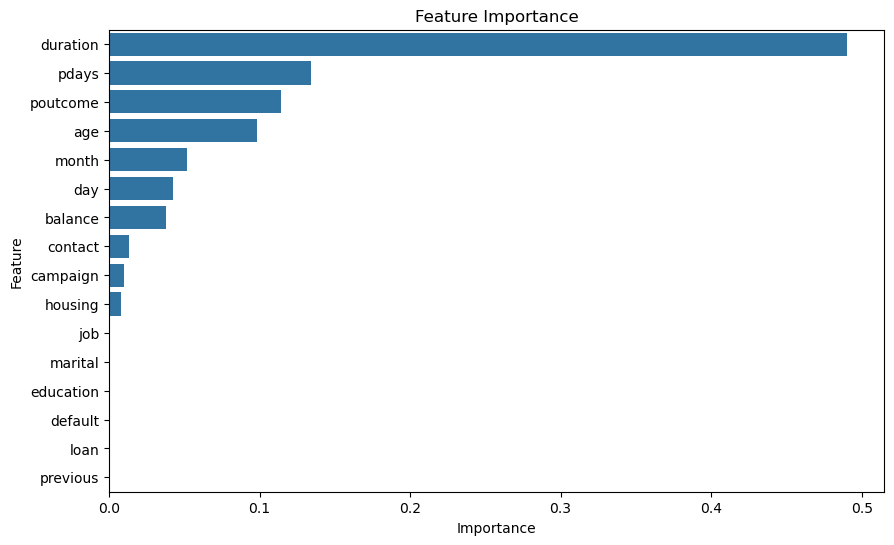

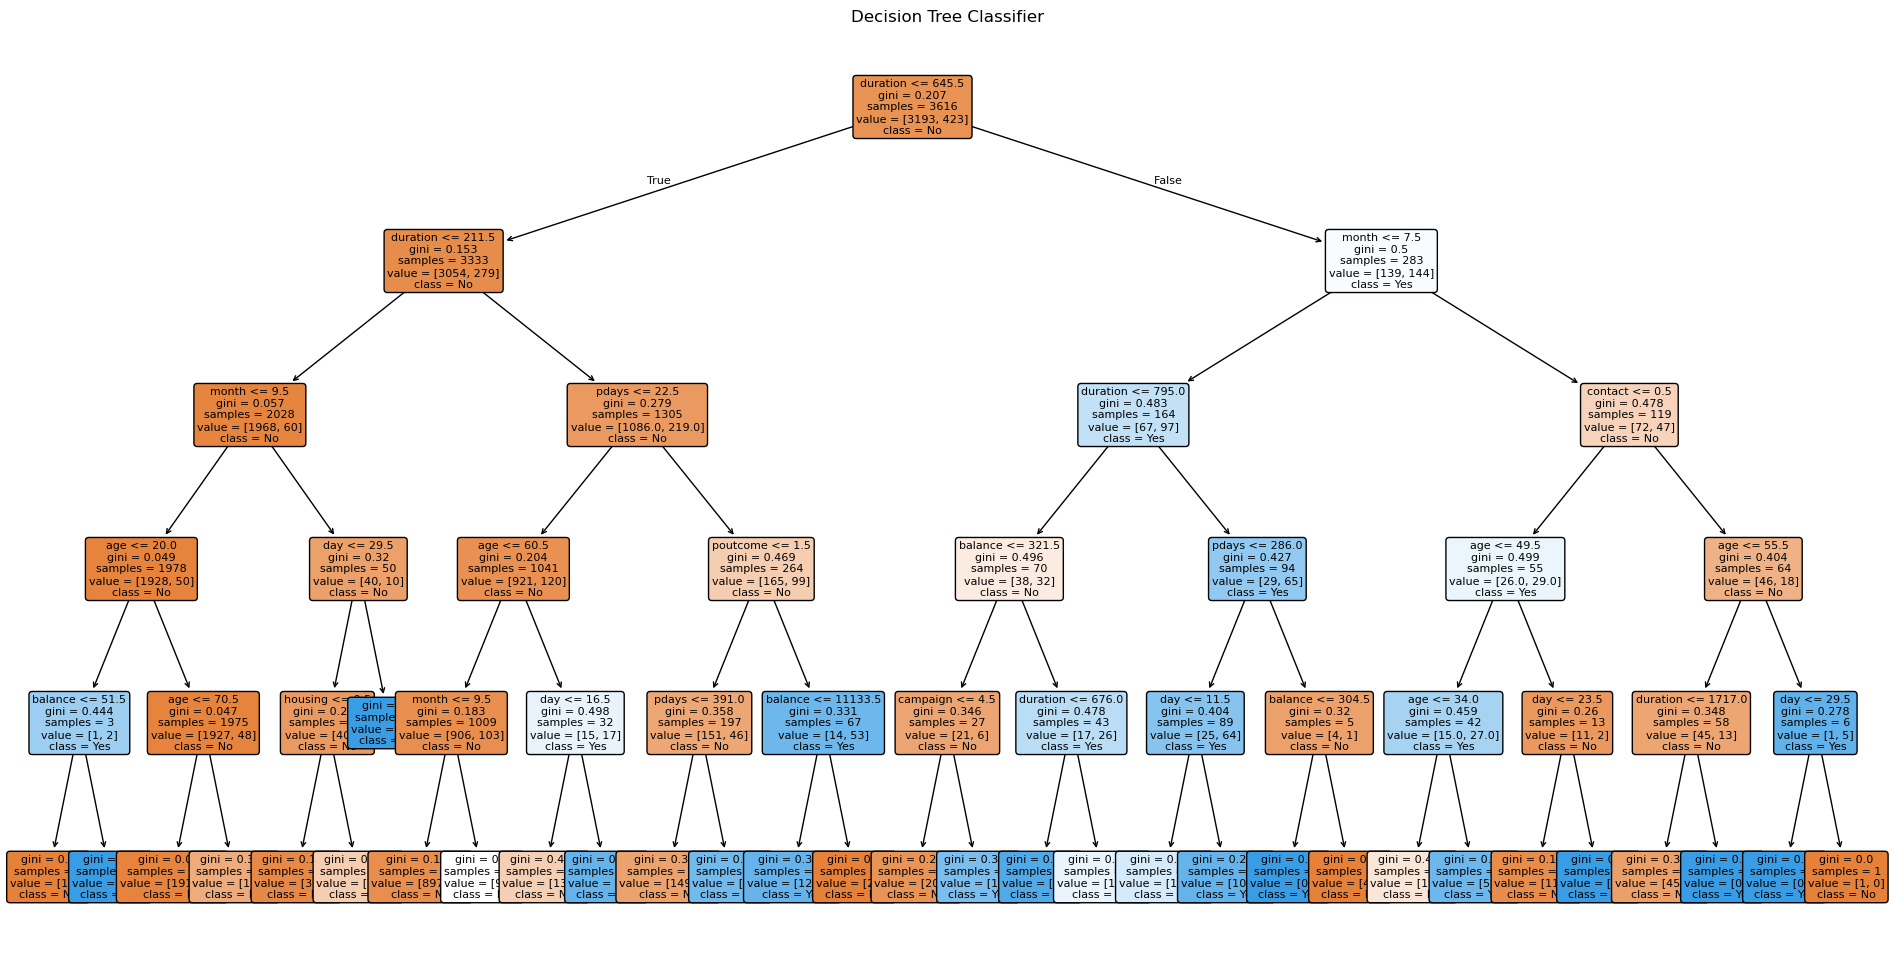


===== PROJECT INSIGHTS =====
1. Decision Tree was trained to predict whether a customer subscribes to a term deposit.
2. The model uses demographic and behavioral features.
3. Feature importance identifies the most influential variables.
4. Confusion matrix shows prediction performance.
5. Decision tree visualization explains how decisions are made.

All visualizations and files have been saved successfully in the 'plots' folder.

Saved Files:
1. confusion_matrix.png
2. feature_importance.png
3. decision_tree_classifier.png
4. feature_importance.csv
5. model_predictions.csv


In [2]:
# ==========================================
# Decision Tree Classifier - Bank Marketing
# SkillCraft Technology Internship Task
# ==========================================

# Import Libraries

import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CREATE FOLDER TO SAVE PLOTS
# ==========================================

os.makedirs("plots", exist_ok=True)

def save_plot(filename):
    plt.savefig(
        f"plots/{filename}.png",
        dpi=300,
        bbox_inches='tight'
    )

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("bank.csv", sep=";")

print("First 5 Rows:")
print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

# ==========================================
# CHECK MISSING VALUES
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# ENCODE CATEGORICAL COLUMNS
# ==========================================

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = label_encoder.fit_transform(df[column])

print("\nEncoded Dataset:")
print(df.head())

# ==========================================
# DEFINE FEATURES AND TARGET
# ==========================================

X = df.drop("y", axis=1)
y = df["y"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ==========================================
# BUILD DECISION TREE MODEL
# ==========================================

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = dt_model.predict(X_test)

# ==========================================
# EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ==========================================
# CONFUSION MATRIX VISUALIZATION
# ==========================================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

save_plot("confusion_matrix")

plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# Save Feature Importance Table
importance.to_csv(
    "plots/feature_importance.csv",
    index=False
)

# ==========================================
# FEATURE IMPORTANCE VISUALIZATION
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

save_plot("feature_importance")

plt.show()

# ==========================================
# DECISION TREE VISUALIZATION
# ==========================================

plt.figure(figsize=(24,12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")

save_plot("decision_tree_classifier")

plt.show()

# ==========================================
# FINAL INSIGHTS
# ==========================================

print("\n===== PROJECT INSIGHTS =====")

print("1. Decision Tree was trained to predict whether a customer subscribes to a term deposit.")

print("2. The model uses demographic and behavioral features.")

print("3. Feature importance identifies the most influential variables.")

print("4. Confusion matrix shows prediction performance.")

print("5. Decision tree visualization explains how decisions are made.")

print("===========================")

# ==========================================
# SAVE MODEL RESULTS
# ==========================================

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.to_csv(
    "plots/model_predictions.csv",
    index=False
)

print("\nAll visualizations and files have been saved successfully in the 'plots' folder.")

print("\nSaved Files:")
print("1. confusion_matrix.png")
print("2. feature_importance.png")
print("3. decision_tree_classifier.png")
print("4. feature_importance.csv")
print("5. model_predictions.csv")